<a href="https://colab.research.google.com/github/yg36/LangGraph-Learnings/blob/main/LangGraph8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from typing import TypedDict, List, Dict
import random
from langgraph.graph import StateGraph, START, END

In [15]:
class AgentState(TypedDict):
  name : str
  number: List[int]
  counter: int

In [16]:
def greet(state: AgentState) -> AgentState:
  state['name'] = f"Hi there, {state['name']}"
  state["counter"] = 0
  return state

def random_node_state(state: AgentState)-> AgentState:
  state["number"].append(random.randint(0,10))
  state["counter"] += 1
  return state

def should_continue(state: AgentState) -> AgentState:
  if state["counter"] < 5:
    print("Entering loop", state["counter"])
    return "loop"
  else:
    return "exit"

In [17]:
graph = StateGraph(AgentState)

graph.add_node("greet", greet)
graph.add_node("random_node", random_node_state)

graph.add_edge("greet", "random_node")

graph.add_conditional_edges("random_node", should_continue,
                            {
                                "loop": "random_node",
                                "exit": END
                            })

graph.add_edge(START, "greet")
app = graph.compile()

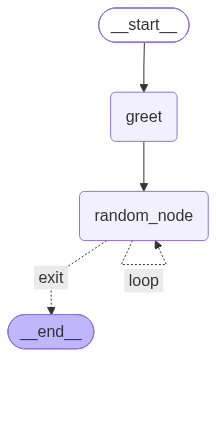

In [18]:
app

In [20]:
app.invoke({"name": "YG", "number": [], "counter": -20})

Entering loop 1
Entering loop 2
Entering loop 3
Entering loop 4


{'name': 'Hi there, YG', 'number': [2, 8, 8, 7, 9], 'counter': 5}